In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1624s 10us/step
Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing images shape: (10000, 32, 32, 3)


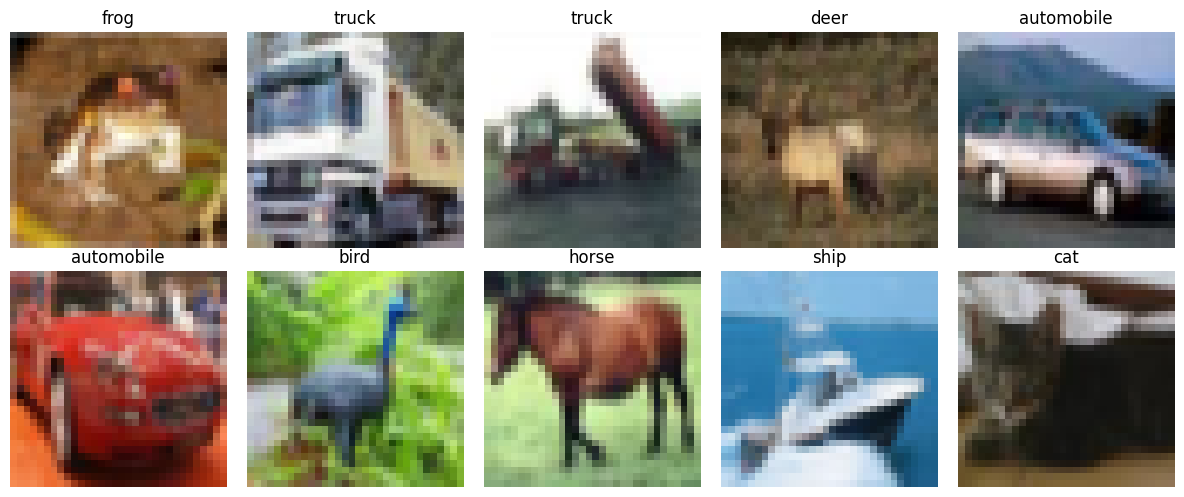

/tmp/ipykernel_1900/4003545108.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[class_names[i] for i in unique], y=counts, palette="viridis")


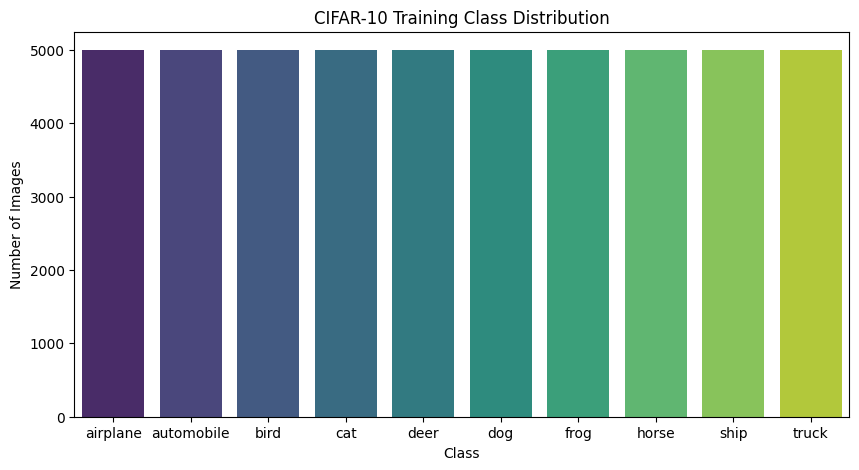

In [ ]:
# Load and normalize dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train.astype("float32") / 255.0, x_test.astype("float32") / 255.0

# Print dataset dimensions
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", x_test.shape)

# 1. Sample Images
plt.figure(figsize=(12, 5))
for i in range(10): # Exactly 10 images
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 2. Class Distribution
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10, 5))
sns.barplot(x=[class_names[i] for i in unique], y=counts, palette="viridis")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("CIFAR-10 Training Class Distribution")
plt.show()

In [ ]:
sample_input = x_train[0:1]

kernels = [(3, 3), (5, 5), (7, 7)]
print("--- Task 2: Kernel Comparison ---")
for k in kernels:
    conv_layer = layers.Conv2D(filters=16, kernel_size=k, padding="valid")
    output = conv_layer(sample_input)
    print(f"Kernel Size: {k} -> Feature Map Size: {output.shape[1:3]}")

--- Task 2: Kernel Comparison ---
Kernel Size: (3, 3) -> Feature Map Size: (30, 30)
Kernel Size: (5, 5) -> Feature Map Size: (28, 28)
Kernel Size: (7, 7) -> Feature Map Size: (26, 26)


In [ ]:
configs = [
    {"stride": 1, "padding": "same"},
    {"stride": 2, "padding": "same"},
    {"stride": 1, "padding": "valid"},
    {"stride": 2, "padding": "valid"}
]

print("\n--- Task 3: Hyperparameter Study ---")
for conf in configs:
    conv_layer = layers.Conv2D(filters=16, kernel_size=(3, 3),
                               strides=conf["stride"], padding=conf["padding"])
    output = conv_layer(sample_input)
    print(f"Stride: {conf['stride']}, Padding: {conf['padding']} -> Output Dimension: {output.shape[1:3]}")


--- Task 3: Hyperparameter Study ---
Stride: 1, Padding: same -> Output Dimension: (32, 32)
Stride: 2, Padding: same -> Output Dimension: (16, 16)
Stride: 1, Padding: valid -> Output Dimension: (30, 30)
Stride: 2, Padding: valid -> Output Dimension: (15, 15)


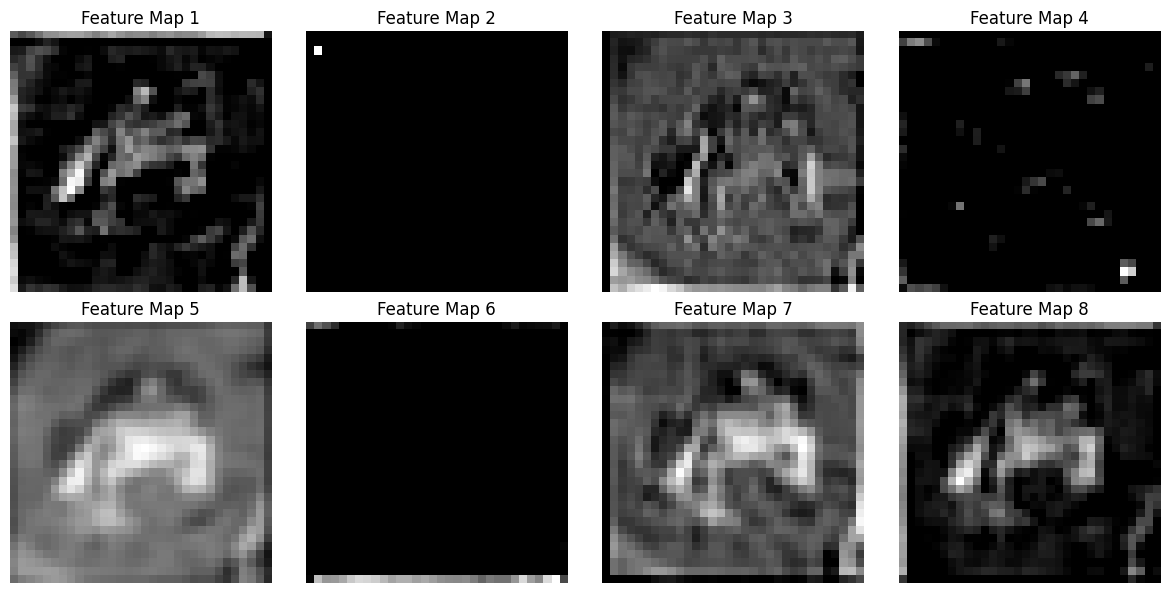

In [ ]:
# Create a single convolution layer and extract features
conv_layer = layers.Conv2D(filters=8, kernel_size=(3, 3), padding="same", activation="relu")
feature_maps = conv_layer(sample_input)

# 7. Mandatory Plot: Feature Maps
plt.figure(figsize=(12, 6))
for i in range(8): # Display 8 feature maps
    plt.subplot(2, 4, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap="gray")
    plt.title(f"Feature Map {i + 1}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:

def build_pooling_model(pooling_type):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)) if pooling_type == 'max' else layers.AveragePooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

print("\n--- Task 5: Pooling Comparison ---")
model_max = build_pooling_model('max')
model_avg = build_pooling_model('avg')

print("Output size after Max Pooling:", model_max.layers[1].output.shape)
print("Output size after Average Pooling:", model_avg.layers[1].output.shape)

# compare accuracy
print("Training Max Pooling Model for 3 epochs...")
model_max.fit(x_train, y_train, epochs=3, batch_size=64, verbose=0)
_, max_acc = model_max.evaluate(x_test, y_test, verbose=0)

print("Training Average Pooling Model for 3 epochs...")
model_avg.fit(x_train, y_train, epochs=3, batch_size=64, verbose=0)
_, avg_acc = model_avg.evaluate(x_test, y_test, verbose=0)

print(f"Max Pooling Test Accuracy: {max_acc:.4f}")
print(f"Average Pooling Test Accuracy: {avg_acc:.4f}")


--- Task 5: Pooling Comparison ---
Output size after Max Pooling: (None, 15, 15, 32)
Output size after Average Pooling: (None, 15, 15, 32)
Training Max Pooling Model for 3 epochs...
Training Average Pooling Model for 3 epochs...
Max Pooling Test Accuracy: 0.5781
Average Pooling Test Accuracy: 0.5686


In [ ]:
# Construct the CNN
main_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"), # Standard hidden dense layer
    layers.Dense(10, activation="softmax")
])

main_model.summary()

# Compile the model
main_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Train the model (Epochs = 20, Batch Size = 32)
history = main_model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 88s 69ms/step - accuracy: 0.5049 - loss: 1.3849 - val_accuracy: 0.6005 - val_loss: 1.1185
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 66ms/step - accuracy: 0.6451 - loss: 1.0163 - val_accuracy: 0.6609 - val_loss: 0.9833
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 65ms/step - accuracy: 0.6935 - loss: 0.8769 - val_accuracy: 0.6690 - val_loss: 0.9599
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 65ms/step - accuracy: 0.7299 - loss: 0.7710 - val_accuracy: 0.6895 - val_loss: 0.8938
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 65ms/step - accuracy: 0.7634 - loss: 0.6733 - val_accuracy: 0.7008 - val_loss: 0.9072


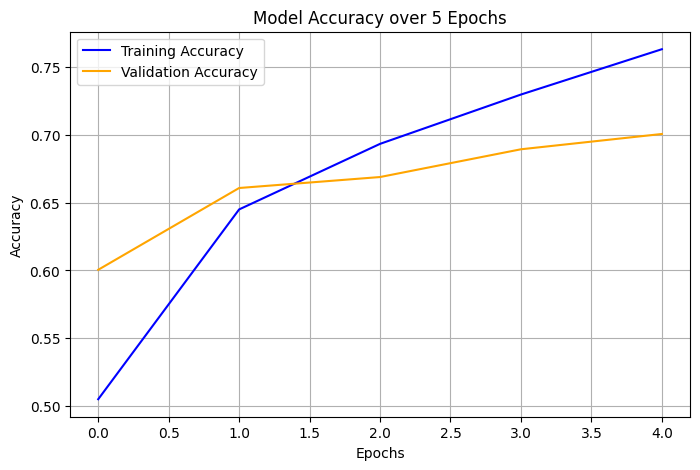

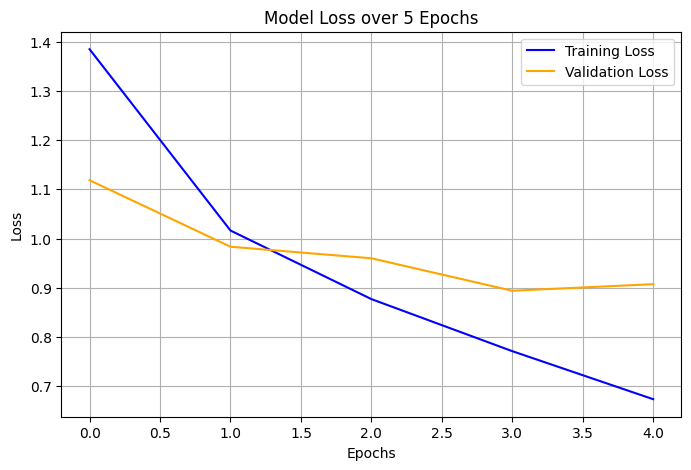

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step

--- Task 7: Evaluation Metrics ---
Accuracy : 0.6918
Precision: 0.6984
Recall   : 0.6918
F1-Score : 0.6927

Classification Report:
               precision    recall  f1-score   support

    airplane       0.71      0.74      0.72      1000
  automobile       0.77      0.85      0.81      1000
        bird       0.56      0.60      0.58      1000
         cat       0.49      0.57      0.53      1000
        deer       0.67      0.62      0.65      1000
         dog       0.61      0.54      0.57      1000
        frog       0.83      0.68      0.75      1000
       horse       0.83      0.70      0.76      1000
        ship       0.78      0.81      0.79      1000
       truck       0.74      0.80      0.77      1000

    accuracy                           0.69     10000
   macro avg       0.70      0.69      0.69     10000
weighted avg       0.70      0.69      0.69     10000



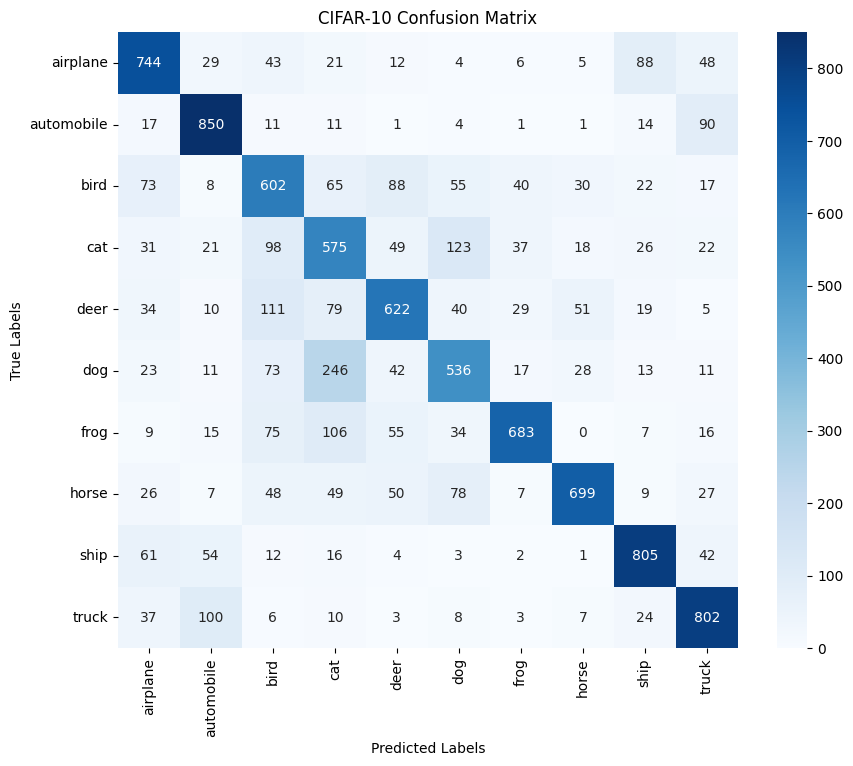

In [ ]:
# 3 & 4. Mandatory Plots: Training & Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy", color='blue')
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", color='orange')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model Accuracy over 5 Epochs")
plt.legend()
plt.grid()
plt.show()

# 5 & 6. Mandatory Plots: Training & Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss", color='blue')
plt.plot(history.history["val_loss"], label="Validation Loss", color='orange')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Model Loss over 5 Epochs")
plt.legend()
plt.grid()
plt.show()

# Evaluation & Metrics Predictions
y_prob = main_model.predict(x_test)
y_pred = np.argmax(y_prob, axis=1)
y_true = y_test.flatten()

# Calculate Metrics
print("\n--- Task 7: Evaluation Metrics ---")
print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred, average='weighted'):.4f}")
print(f"F1-Score : {f1_score(y_true, y_pred, average='weighted'):.4f}")

# Classification Report
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

# 8. Mandatory Plot: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("CIFAR-10 Confusion Matrix")
plt.show()

In [ ]:
# --- Additional Exercise 5: 16 vs 64 Filters ---
import time

def build_filter_test_model(filters):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(filters, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Test 16 Filters
model_16 = build_filter_test_model(16)
start_time = time.time()
model_16.fit(x_train, y_train, epochs=5, batch_size=32, verbose=0)
time_16 = time.time() - start_time
acc_16 = model_16.evaluate(x_test, y_test, verbose=0)[1]

# Test 64 Filters
model_64 = build_filter_test_model(64)
start_time = time.time()
model_64.fit(x_train, y_train, epochs=5, batch_size=32, verbose=0)
time_64 = time.time() - start_time
acc_64 = model_64.evaluate(x_test, y_test, verbose=0)[1]

print(f"16 Filters -> Accuracy: {acc_16:.4f} | Training Time (5 epochs): {time_16:.2f} seconds")
print(f"64 Filters -> Accuracy: {acc_64:.4f} | Training Time (5 epochs): {time_64:.2f} seconds")
print("Analysis: Increasing filters from 16 to 64 allows the network to extract more diverse features, typically leading to higher accuracy. However, this dramatically increases the number of trainable parameters, resulting in a noticeable increase in computation time per epoch.")

16 Filters -> Accuracy: 0.6089 | Training Time (5 epochs): 178.23 seconds
64 Filters -> Accuracy: 0.6428 | Training Time (5 epochs): 383.11 seconds
Analysis: Increasing filters from 16 to 64 allows the network to extract more diverse features, typically leading to higher accuracy. However, this dramatically increases the number of trainable parameters, resulting in a noticeable increase in computation time per epoch.
